In [145]:
# load necessary libraries
import json
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import defaultdict
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader
import torch.optim as optim
from sklearn.decomposition import PCA


# load the dictionary terms
groups_dictionary = pd.read_csv("../01_data/dictionary/groups_dictionary_cl.csv")

# load the ground truth data with augmentations
with open("../01_data/annotations/annotations_augmentations.json") as f:
    gt_augmentations = json.load(f)

In [146]:
# create a single list of all dictionary entries paired with their category
mention_list = []
category_list = []
categories = groups_dictionary.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dictionary[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry)
            category_list.append(category)

category_list = [cat for cat in category_list]

df = pd.DataFrame({'mention': mention_list, 'category': category_list})

def duplicate_minimum(df, min_count=5):
    new_rows = []
    for cat in df['category'].unique():
        entries = df[df['category'] == cat]
        n = len(entries)
        if n < min_count:
            repeats = min_count - n
            sampled = entries.sample(repeats, replace=True)
            new_rows.append(sampled)
    if new_rows:
        df = pd.concat([df] + new_rows, ignore_index=True)
    return df

df = duplicate_minimum(df, min_count=5)

mention_list = df["mention"].to_list()
category_list = df["category"].to_list()

In [152]:
category_to_indices = defaultdict(list)

for idx, cat in enumerate(category_list):
    category_to_indices[cat].append(idx)

class BalancedDataset(Dataset):
    def __init__(self, mentions, labels):
        self.mentions = mentions
        self.labels = labels
    
    def __len__(self):
        return len(self.mentions)
    
    def __getitem__(self, idx):
        return self.mentions[idx], self.labels[idx]

def balanced_batch_sampler(category_to_indices, categories_per_batch, samples_per_category, batches_per_epoch):
    categories = list(category_to_indices.keys())
    for _ in range(batches_per_epoch):
        batch_indices = []
        selected_cats = random.sample(categories, categories_per_batch)
        for cat in selected_cats:
            indices = category_to_indices[cat]
            chosen = random.choices(indices, k=samples_per_category)
            batch_indices.extend(chosen)
        yield batch_indices

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def collate_fn(batch):
    texts, labels = zip(*batch)
    encodings = tokenizer(list(texts), padding=True, truncation=True, return_tensors='pt')
    labels = torch.tensor([cat2id[l] for l in labels])
    return encodings['input_ids'], encodings['attention_mask'], labels

dataset = BalancedDataset(mention_list, category_list)
batch_sampler = balanced_batch_sampler(category_to_indices, categories_per_batch=5, samples_per_category=3, batches_per_epoch=25)

dataloader = DataLoader(dataset, batch_sampler=batch_sampler, collate_fn=lambda batch: collate_fn(batch))

In [148]:
class SpanEncoder(nn.Module):
    def __init__(self, model_name="roberta-base"):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = outputs.last_hidden_state.mean(dim=1)
        return embeddings

def supervised_contrastive_loss(embeddings, labels, temperature=0.05):
    embeddings = F.normalize(embeddings, dim=1)
    sim_matrix = torch.matmul(embeddings, embeddings.T) / temperature

    labels = labels.unsqueeze(1)
    
    mask = torch.eq(labels, labels.T).float()  # positives mask
    mask.fill_diagonal_(0)  # remove self-similarity

    pos_counts = mask.sum(1)
    valid = pos_counts > 0
    pos_counts = torch.clamp(pos_counts, min=1)

    log_prob = F.log_softmax(sim_matrix, dim=1)
    mean_log_prob_pos = (mask * log_prob).sum(1) / pos_counts
    loss = -mean_log_prob_pos[valid].mean()
    return loss

In [155]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SpanEncoder().to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

for epoch in range(50):
    total_loss = 0
    for batch in dataloader:
        input_ids, attention_mask, batch_labels = [x.to(device) for x in batch]

        embeddings = model(input_ids, attention_mask)
        loss = supervised_contrastive_loss(embeddings, batch_labels)
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss = total_loss / len(dataloader)

    print(f"Epoch {epoch+1}, Average Batch Loss: {avg_loss:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1, Average Batch Loss: 0.0000
Epoch 2, Average Batch Loss: 0.0000
Epoch 3, Average Batch Loss: 0.0000
Epoch 4, Average Batch Loss: 0.0000
Epoch 5, Average Batch Loss: 0.0000
Epoch 6, Average Batch Loss: 0.0000
Epoch 7, Average Batch Loss: 0.0000
Epoch 8, Average Batch Loss: 0.0000
Epoch 9, Average Batch Loss: 0.0000
Epoch 10, Average Batch Loss: 0.0000
Epoch 11, Average Batch Loss: 0.0000
Epoch 12, Average Batch Loss: 0.0000
Epoch 13, Average Batch Loss: 0.0000
Epoch 14, Average Batch Loss: 0.0000
Epoch 15, Average Batch Loss: 0.0000
Epoch 16, Average Batch Loss: 0.0000
Epoch 17, Average Batch Loss: 0.0000
Epoch 18, Average Batch Loss: 0.0000
Epoch 19, Average Batch Loss: 0.0000
Epoch 20, Average Batch Loss: 0.0000
Epoch 21, Average Batch Loss: 0.0000
Epoch 22, Average Batch Loss: 0.0000
Epoch 23, Average Batch Loss: 0.0000
Epoch 24, Average Batch Loss: 0.0000
Epoch 25, Average Batch Loss: 0.0000
Epoch 26, Average Batch Loss: 0.0000
Epoch 27, Average Batch Loss: 0.0000
Epoch 28, 

In [91]:
model.eval()

with torch.no_grad():
    all_embeddings = []

    for batch in dataloader:
        input_ids, attention_mask, batch_labels = [x.to(device) for x in batch]
        embeddings = model(input_ids, attention_mask)
        all_embeddings.append(embeddings.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
labels_np = label_ids.numpy()

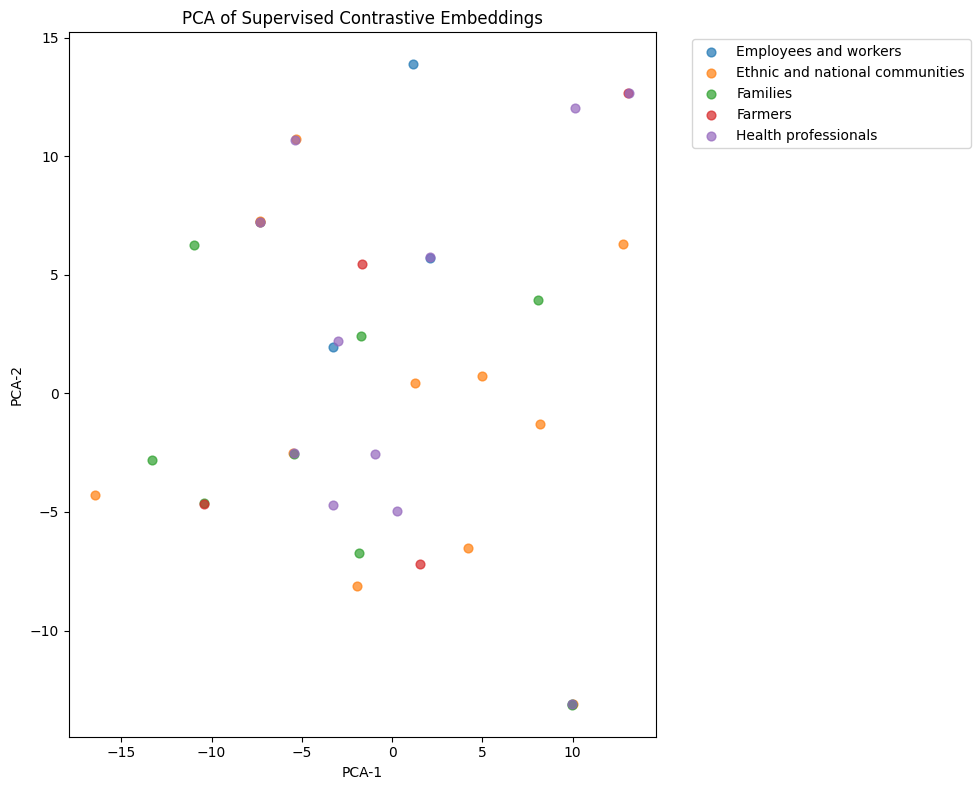

In [94]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings)


plt.figure(figsize=(10, 8))
categories = list(cat2id.keys())
num_classes = len(categories)

for c in range(10, 15):
    idx = np.where(labels_np == c)[0]
    if len(idx) == 0:
        continue
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        label=categories[c],
        alpha=0.7,
        s=40
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("PCA of Supervised Contrastive Embeddings")
plt.tight_layout()
plt.show()
